## 基于 network data 计算 SMD 

In [25]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns

In [75]:
Net_Edge_DF = pd.read_csv(r"Data\Code_Original\n1_node_ed1.csv")
Net_Edge_DF = Net_Edge_DF[['source_treat','source_num_treat','id_num_treat','source_num_control','id_num_control']]
Net_Edge_DF['source_treat'] = [eval(i)[0] for i in Net_Edge_DF['source_treat']]
Net_Edge_DF = Net_Edge_DF.drop_duplicates().sort_values('source_treat').reset_index(drop = True)
for col in ['source_num_treat','id_num_treat','source_num_control','id_num_control']:
    Net_Edge_DF[col] = Net_Edge_DF[col].astype(int)

In [15]:
def SMD(input):
    treat_count   = input[0]
    treat_num     = input[1]
    control_count = input[2]
    control_num   = input[3]

    treat_ls   = [1]*treat_count + [0] * (treat_num - treat_count)
    control_ls = [1]*control_count + [0] * (control_num - control_count)
    mean_treat = np.mean(treat_ls)
    var_treat  = np.var(treat_ls)
    mean_control = np.mean(control_ls)
    var_control  = np.var(control_ls)   

    outcome = np.abs(mean_treat-mean_control) / np.sqrt((var_treat + var_control) / 2)
    return outcome

In [ ]:
Net_Edge_DF['SMD'] = Net_Edge_DF[['source_num_treat','id_num_treat','source_num_control','id_num_control']].apply(SMD,axis = 1)
Net_Edge_DF['source_ratio_treat'] = Net_Edge_DF['source_num_treat']/Net_Edge_DF['id_num_treat']
Net_Edge_DF['source_ratio_control'] = Net_Edge_DF['source_num_control']/Net_Edge_DF['id_num_control']
Net_Edge_DF.sort_values('SMD')

## 匹配数据

In [27]:
net1_E_refine = pd.read_csv("Data\Code_01_Outcome\network_pairwise.csv")
net1_E_refine['target'] = net1_E_refine['target'].str.split('_').str.get(1)

In [34]:
net1_E_refine['edge'] = net1_E_refine['source'].str.split('_').str.get(1).str.cat(net1_E_refine['target'].str.split('_').str.get(1),sep = '_')
net1_E_refine['source'] = net1_E_refine['source'].str.split('_').str.get(1)

In [47]:
net1_E_refine_ = net1_E_refine[['source','source_num_treat','id_num_treat','source_num_control','id_num_control']]

In [44]:
Net_Edge_DF.columns = ['source', 'source_num_treat', 'id_num_treat',
       'source_num_control', 'id_num_control', 'SMD', 'source_ratio_treat',
       'source_ratio_control']

In [ ]:
net1_E_refine = pd.merge(net1_E_refine,Net_Edge_DF[['source','SMD', 'source_ratio_treat','source_ratio_control']],on = 'source',how = 'left')

In [61]:
net1_E_refine.columns

Index(['edge', 'edge_num_treat', 'source', 'target', 'source_num_treat',
       'target_num_treat', 'id_num_treat', 'RR_treat', 'Correlation_treat',
       'RR_norm_treat', 'Correlation_norm_treat', 'edge_num_control',
       'source_control', 'target_control', 'source_num_control',
       'target_num_control', 'id_num_control', 'RR_control',
       'Correlation_control', 'RR_norm_control', 'Correlation_norm_control',
       'p_value', 'p_value_group', 'Correlation_Ratio', 'RR_Ratio',
       'Correlation_abs', 'RR_abs', 'SMD', 'source_ratio_treat',
       'source_ratio_control'],
      dtype='object')

In [66]:
net1_E_refine_ = net1_E_refine[['source','SMD','source_num_treat','source_num_control','source_ratio_treat','source_ratio_control']]

In [67]:
net1_E_refine_ = net1_E_refine_.drop_duplicates().reset_index(drop = True )

In [68]:
for col in ['source_num_treat','source_num_control']:
    net1_E_refine_[col] = net1_E_refine_[col].astype(int)

In [71]:
net1_E_refine_.head()

,source,SMD,source_num_treat,source_num_control,source_ratio_treat,source_ratio_control
0,401,0.020677,10912,33765,0.185863,0.193973
1,780,0.043090,6375,21298,0.108585,0.122352
2,493,0.022838,504,1884,0.008585,0.010823
3,079,0.130908,1393,1310,0.023727,0.007526
4,519,0.152372,1157,601,0.019707,0.003453


###  Plot1 Bar Plot about SMD 
###  Plot2 Bar Plot about Difference
###  Plot3 Bar Plot about ABS Value Difference

In [72]:
net1_E_refine_ = net1_E_refine_.sort_values('SMD',ascending=False).reset_index(drop = True)

In [86]:
net1_E_refine_.head()

,source,SMD,source_num_treat,source_num_control,source_ratio_treat,source_ratio_control
0,519,0.152372,1157,601,0.019707,0.003453
1,079,0.130908,1393,1310,0.023727,0.007526
2,427,0.054722,2685,10071,0.045733,0.057856
3,599,0.050504,3840,13656,0.065406,0.078451
4,486,0.049363,2814,10276,0.047931,0.059033


In [ ]:
mean = np.mean(net1_E_refine_['SMD'].tolist())
fig = plt.figure(figsize=(12,8))
categories = net1_E_refine_['source'].tolist()
value_1 = net1_E_refine_['SMD'].tolist()
bar_width = 0.5
bar_positions1 = np.arange(len(categories))
plt.bar(bar_positions1, value_1, width=bar_width, label='Source Condition')
plt.axhline(y=mean,color='red', linestyle='--', label='SMD Mean Value')
plt.title('Condition SMD (Standardized Mean Difference)')
plt.xlabel('ICD 9 Code')
plt.ylabel('SMD')
# 设置x轴刻度标签
plt.xticks(bar_positions1 + bar_width / 2, categories,rotation = 90,fontsize = 8)
# 添加图例
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


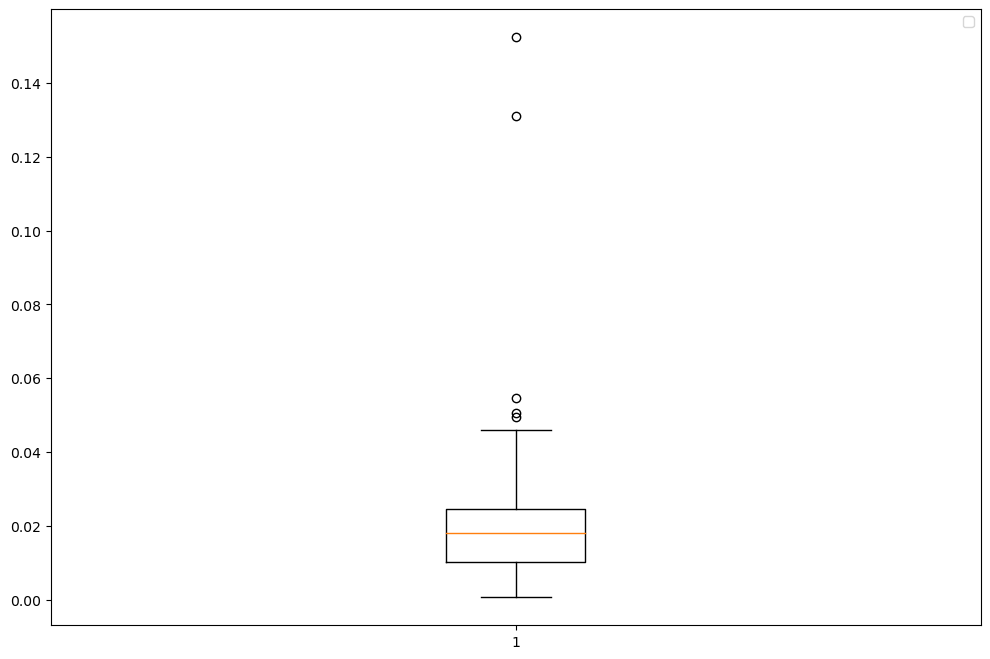

In [127]:
fig = plt.figure(figsize=(12,8))
value_1 = net1_E_refine_['SMD'].tolist()
bar_positions1 = np.arange(len(categories))
plt.boxplot(value_1)
# 添加图例
plt.legend()
plt.show()

In [108]:
net1_E_refine_['ratio_difference'] = (net1_E_refine_['source_ratio_treat'] - net1_E_refine_['source_ratio_control'])/net1_E_refine_['source_ratio_control']

In [114]:
net1_E_refine_ = net1_E_refine_.sort_values('ratio_difference',ascending=False)

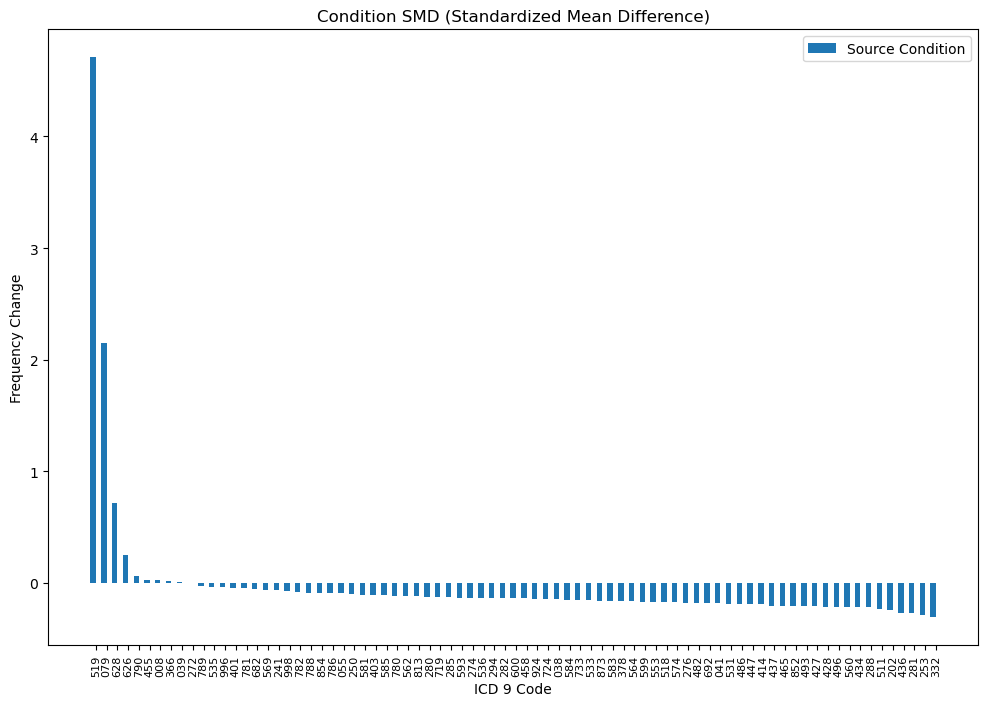

In [123]:
# mean = np.mean(net1_E_refine_['ratio_difference'].tolist())
fig = plt.figure(figsize=(12,8))
categories = net1_E_refine_['source'].tolist()
value_1 = net1_E_refine_['ratio_difference'].tolist()
bar_width = 0.5
bar_positions1 = np.arange(len(categories))
plt.bar(bar_positions1, value_1, width=bar_width, label='Source Condition')
# plt.axhline(y=mean,color='red', linestyle='--', label='SMD Mean Value')
plt.title('Condition SMD (Standardized Mean Difference)')
plt.xlabel('ICD 9 Code')
plt.ylabel('Frequency Change')
# 设置x轴刻度标签
plt.xticks(bar_positions1 + bar_width / 2, categories,rotation = 90,fontsize = 8)
# 添加图例
plt.legend()
plt.show()

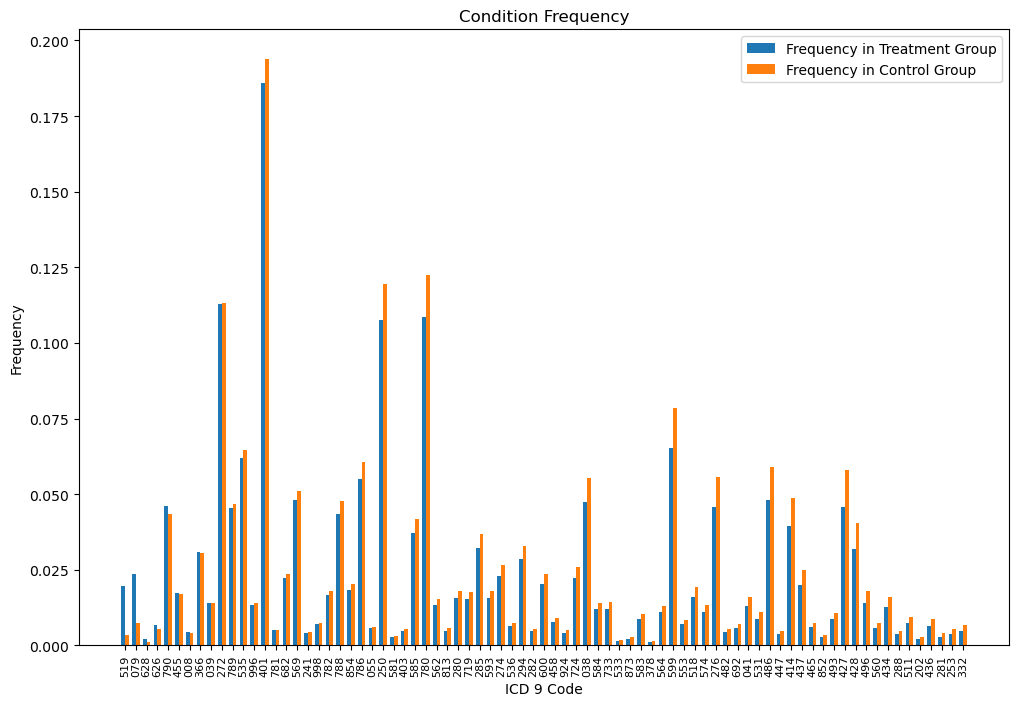

In [124]:
fig = plt.figure(figsize=(12,8))
categories = net1_E_refine_['source'].tolist()
value_1 = net1_E_refine_['source_ratio_treat'].tolist()
value_2 = net1_E_refine_['source_ratio_control'].tolist()
bar_width = 0.35
bar_positions1 = np.arange(len(categories))
bar_positions2 = bar_positions1 + bar_width
# 创建柱状图，并指定颜色
plt.bar(bar_positions1, value_1, width=bar_width, label='Frequency in Treatment Group')
plt.bar(bar_positions2, value_2, width=bar_width, label='Frequency in Control Group')
# 添加标题和轴标签
# 添加标题和轴标签
plt.title('Condition Frequency')
plt.xlabel('ICD 9 Code')
plt.ylabel('Frequency')
# 设置x轴刻度标签
plt.xticks(bar_positions1 + bar_width / 2, categories,rotation = 90,fontsize = 8)
# 添加图例
plt.legend()
# 显示图形
plt.show()